In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
sc.settings.verbosity = 3

# Instead of set_figure_params, configure matplotlib manually
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['savefig.dpi'] = 100


/home/krupavardhan4869@gmail.com/disenv/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
from models.harmony import run_harmony_integration
from models.scanorama import run_scanorama_integration
from models.scVI_model import run_scvi_integration
from models.scETM import run_scetm_integration

ModuleNotFoundError: No module named 'models'

In [ ]:
%matplotlib inline

In [3]:
# Load data
adata_unharmonized = sc.read_h5ad('downloaded_adata_diseases_unharmonized.h5ad')
adata_harmonized = sc.read_h5ad('downloaded_adata_diseases_harmonized.h5ad')


In [4]:
parse_data = sc.read_h5ad('adata_parse.h5ad')

In [5]:
parse_data.shape

(998713, 5634)

In [43]:
print(adata_unharmonized.obs.columns)
print("    ")
print(parse_data.obs.columns)

Index(['dataset_id', 'donor_id', 'tissue_general', 'perturbation',
       'chunk_number', 'filename', 'cell_index', 'dataset_dir',
       'cell_type_original', 'filepath', 'filepath_harmonized', 'state',
       'cell_type_level1', 'total_counts', 'n_nonzero_genes', 'max_count'],
      dtype='object')
    
Index(['sample', 'species', 'gene_count', 'tscp_count', 'mread_count',
       'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well',
       'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT',
       'pct_counts_MT', 'log1p_total_counts_MT', 'donor', 'cytokine',
       'treatment', 'cell_type', 'total_counts', 'cell_type_level1',
       'cell_type_level2'],
      dtype='object')


In [ ]:
adata_unharmonized.obs['perturbation'].value_counts()

perturbation
B-cell acute lymphoblastic leukemia           78000
COVID-19                                      78000
hematologic disorder                          78000
juvenile dermatomyositis                      78000
myelodysplastic syndrome                      78000
myelodysplastic/myeloproliferative disease    78000
normal                                        78000
post-COVID-19 disorder                        78000
respiratory system disorder                   78000
systemic lupus erythematosus                  78000
Name: count, dtype: int64

In [ ]:
dataset = '4a5b00e0-1ba3-4fd4-af89-d3512eb20720'
adata_unharmonized = adata_unharmonized[adata_unharmonized.obs['dataset_id']==dataset]
adata_unharmonized.shape


(131052, 5634)

In [87]:
adata_harmonized = adata_harmonized[adata_harmonized.obs['dataset_id']==dataset]
adata_harmonized.shape


(131052, 5634)

In [88]:
adata_unharmonized.obs['batch'] ='batch1'
adata_harmonized.obs['batch'] ='batch1'

In [63]:
sample_size = 131052
parse_data = parse_data[:sample_size]
parse_data.shape
parse_data.obs['batch'] ='batch2'


In [89]:
adata_unharmonized.var_names = [str(i) for i in range(adata_unharmonized.n_vars)]
parse_data.var_names = [str(i) for i in range(parse_data.n_vars)]
adata_unharmonized.var_names = [str(i) for i in range(adata_unharmonized.n_vars)]


In [90]:
combined_data = sc.concat([parse_data, adata_unharmonized], axis=0,join='inner')

In [91]:
combined_har_data = sc.concat([parse_data, adata_harmonized], axis=0,join='inner')

In [92]:
combined_har_data.obs

,total_counts,cell_type_level1,batch
73_133_056__s86,1078.0,T_cell,batch2
93_051_116__s22,717.0,T_cell,batch2
87_063_147__s32,991.0,T_cell,batch2
92_158_091__s47,1787.0,T_cell,batch2
68_181_116__s88,1317.0,T_cell,batch2
...,...,...,...
349470,610.0,b_cell,batch1
349928,325.0,b_cell,batch1
350055,418.0,b_cell,batch1
350508,386.0,b_cell,batch1


In [52]:
# print(adata_unharmonized.obs['cell_type_level1'].value_counts())
# print("    ")

In [53]:

# print(parse_data.obs['cell_type_level1'].value_counts())
# print("    ")

In [58]:
parse_data.obs['treatment'].value_counts()

treatment
cytokine    934437
PBS          64276
Name: count, dtype: int64

In [25]:
samples =  ["Donor1_PBS",'Donor2_PBS']
parse_data = parse_data[parse_data.obs['sample'].isin(samples)]
parse_data.shape
parse_data.obs['sample'].value_counts()


sample
Donor1_PBS    9407
Donor2_PBS    7119
Name: count, dtype: int64

normalizing counts per cell
    finished (0:00:00)
computing PCA
    with n_comps=50
    finished (0:00:57)
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:35)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:02:43)


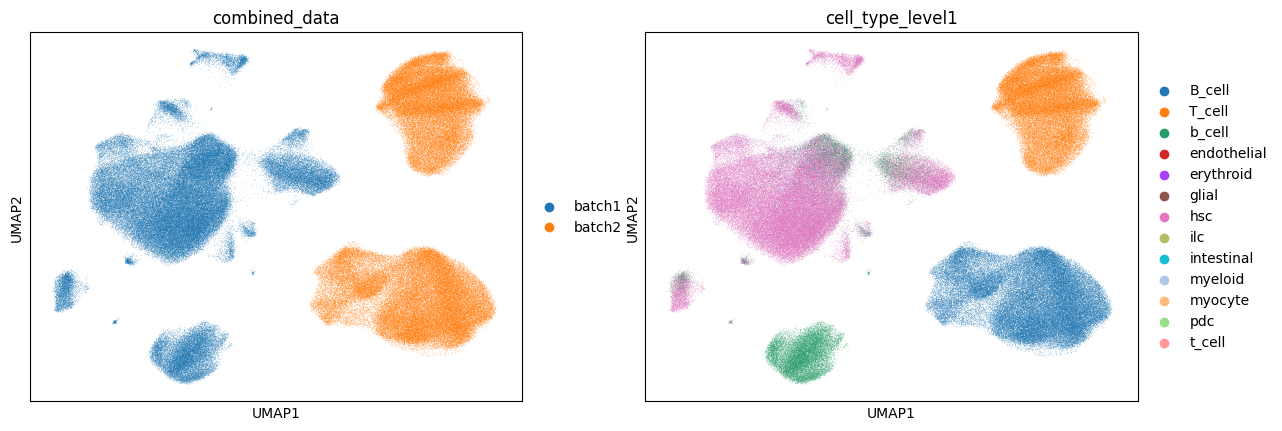

In [ ]:
sc.pp.normalize_total(combined_data, target_sum=1e4)
sc.pp.log1p(combined_data)
sc.pp.pca(combined_data,n_comps=50)
sc.pp.neighbors(combined_data,use_rep='X_pca')
sc.tl.umap(combined_data)
sc.pl.umap(combined_data, color=["batch","cell_type_level1"], title="unharmonized",show=True)

In [ ]:
sc.pp.normalize_total(combined_har_data, target_sum=1e4)
sc.pp.log1p(combined_har_data)
sc.pp.pca(combined_har_data,n_comps=50)
sc.pp.neighbors(combined_har_data,use_rep='X_pca')
sc.tl.umap(combined_har_data)
sc.pl.umap(combined_har_data, color=["batch","cell_type_level1"], title="harmonized",show=True)

In [86]:
# for i in list(adata_unharmonized.obs['dataset_id'].value_counts().index):
#     print(i, adata_unharmonized.obs['dataset_id'].value_counts()[i])


In [93]:
# dataset_ids = ["84230ea4-998d-4aa8-8456-81dd54ce23af",'79ef1959-a6b4-4cac-82ca-30feaec48df1']


# mask = adata_unharmonized.obs["dataset_id"].isin(dataset_ids)
# adata_unharmonized_sample = adata_unharmonized[mask].copy()

# mask = adata_harmonized.obs["dataset_id"].isin(dataset_ids)
# adata_harmonized_sample=adata_harmonized[mask].copy()

In [10]:
# adata_unharmonized_sample.obs['cell_type_original'].value_counts()

In [11]:
# adata_unharmonized_sample.obs['cell_type_original'].value_counts()


In [ ]:
run_scvi_integration(combined_data,batch_key = 'batch')

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training scVI using **GPU**
Epoch 1/5:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 5/5: 100%|██████████| 5/5 [00:02<00:00,  2.56it/s, v_num=1, train_loss_step=1.82e+3, train_loss_epoch=1.99e+3]

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 5/5: 100%|██████████| 5/5 [00:02<00:00,  2.37it/s, v_num=1, train_loss_step=1.82e+3, train_loss_epoch=1.99e+3]


array([[-0.71911156, -6.467583  ,  3.0126138 , ..., -0.57030016,
         1.6058402 ,  1.4359231 ],
       [ 4.5726194 ,  1.0308368 ,  2.9992292 , ..., -1.6814961 ,
        -1.398656  ,  4.5918617 ],
       [ 0.7369957 , -6.062526  ,  1.9667275 , ..., -0.6561654 ,
         1.2463974 ,  0.03203053],
       ...,
       [ 0.9237479 ,  0.71903   ,  0.10972333, ..., -0.23350747,
        -0.40996236,  1.3846933 ],
       [ 0.43319377,  1.2318355 ,  2.5427382 , ..., -0.7896065 ,
        -0.19528805,  3.6916375 ],
       [ 3.6015778 ,  1.5574523 ,  3.1742728 , ..., -1.3138767 ,
        -1.9583385 ,  2.211935  ]], shape=(6001, 10), dtype=float32)

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:04)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:05)


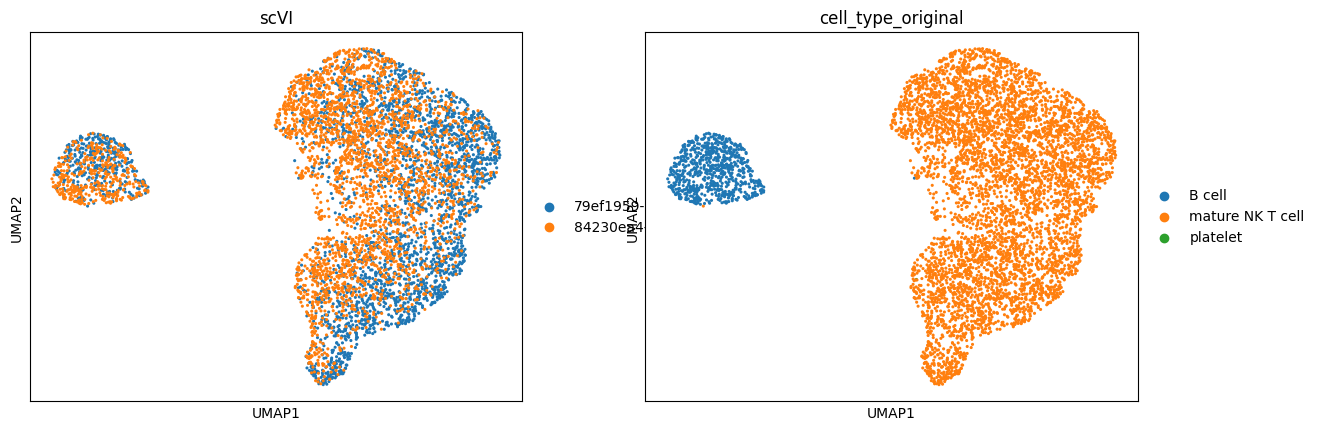

In [ ]:
sc.pp.neighbors(combined_data,use_rep='X_scvi')
sc.tl.umap(combined_data)

sc.pl.umap(combined_data, color=["dataset_id","cell_type_original"], title="scVI",show=True)

In [ ]:
combined_data.obsm['X_scanorama']=run_scanorama_integration(combined_data,)
combined_data.obsm

Found 5634 genes among all datasets


[[0.         0.92033333]
 [0.         0.        ]]
Processing datasets (0, 1)


AxisArrays with keys: X_scvi, X_umap, X_scanorama

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:05)


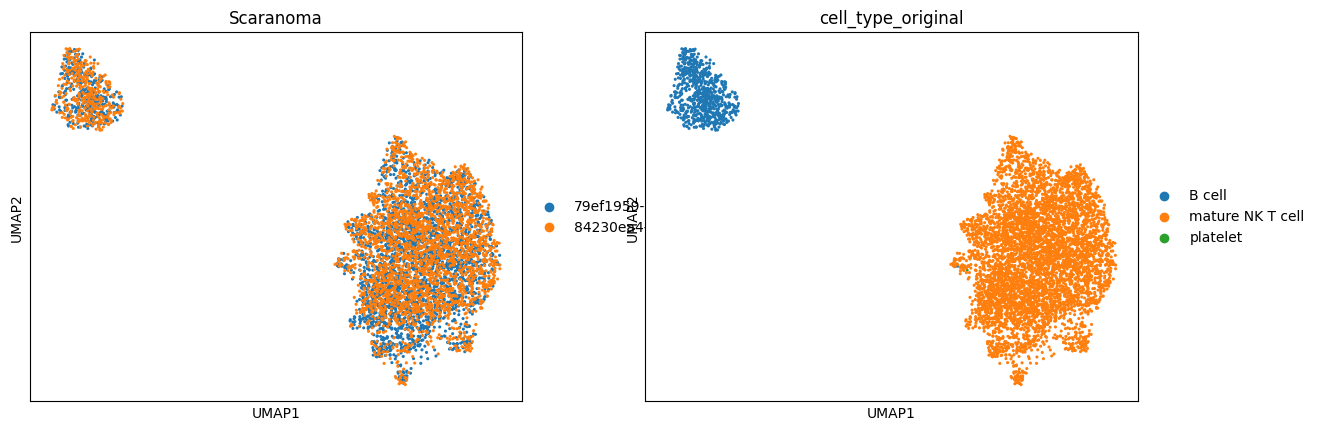

In [15]:
sc.pp.neighbors(adata_unharmonized_sample,use_rep='X_scanorama')
sc.tl.umap(adata_unharmonized_sample)

sc.pl.umap(adata_unharmonized_sample, color=["dataset_id","cell_type_original"], title="Scaranoma",show=True)

In [ ]:
sc.pp.normalize_total(combined_data, target_sum=1e4)
sc.pp.log1p(combined_data)
sc.pp.pca(combined_data,n_comps=50)

normalizing counts per cell
    finished (0:00:00)
computing PCA
    with n_comps=50
    finished (0:00:01)


computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:05)


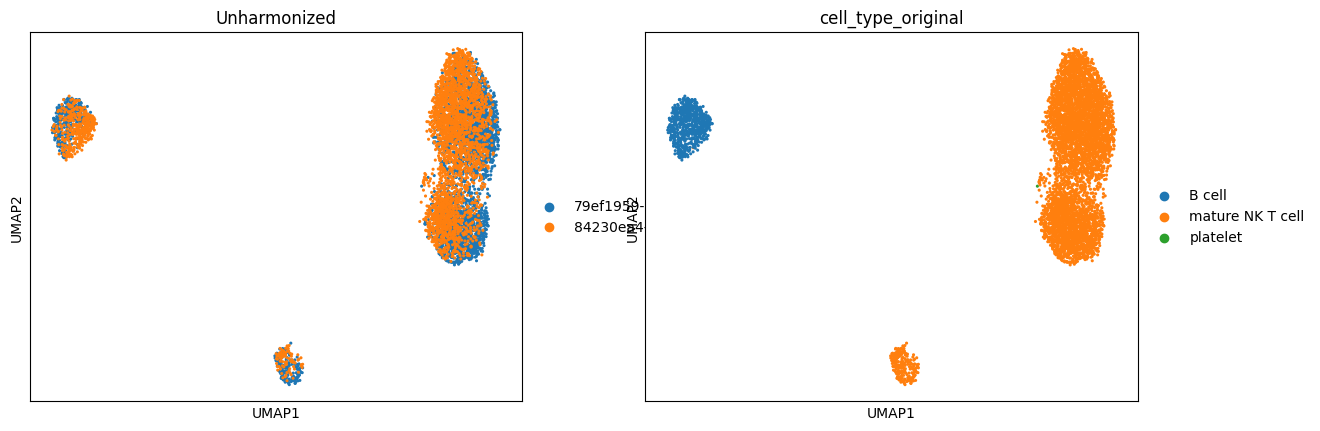

In [ ]:
sc.pp.neighbors(combined_data,use_rep='X_pca')
sc.tl.umap(combined_data)

sc.pl.umap(combined_data, color=["batch","cell_type_level1"], title="Unharmonized",show=True)

In [ ]:
run_harmony_integration(combined_data,batch_key = 'batch')

2025-09-03 07:29:26,697 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-09-03 07:29:27,601 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-09-03 07:29:27,613 - harmonypy - INFO - Iteration 1 of 20
2025-09-03 07:29:28,228 - harmonypy - INFO - Iteration 2 of 20
2025-09-03 07:29:28,824 - harmonypy - INFO - Iteration 3 of 20
2025-09-03 07:29:29,220 - harmonypy - INFO - Converged after 3 iterations


array([[ -1.9504812 ,  11.368402  ,   6.185606  , ...,   0.11955386,
         -0.10675283,  -1.4527802 ],
       [ -4.2444444 , -11.373343  ,  -5.303238  , ...,   1.1350087 ,
          0.3858216 ,  -0.4389279 ],
       [  0.12041133,  16.512339  ,  -4.8665295 , ...,  -2.3704524 ,
         -0.22917762,  -1.2728437 ],
       ...,
       [ -4.559082  ,  -0.29957658,  -2.149455  , ...,   0.35401493,
         -1.6431006 ,  -2.2405486 ],
       [ -5.7533135 ,  -5.057776  ,   5.8738894 , ...,   0.99662197,
          0.57703906,   0.72673744],
       [ -3.561634  ,  -9.055873  ,  -2.5432677 , ...,  -0.78965235,
         -1.0705124 ,   0.86623484]], shape=(6001, 50), dtype=float32)

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:05)


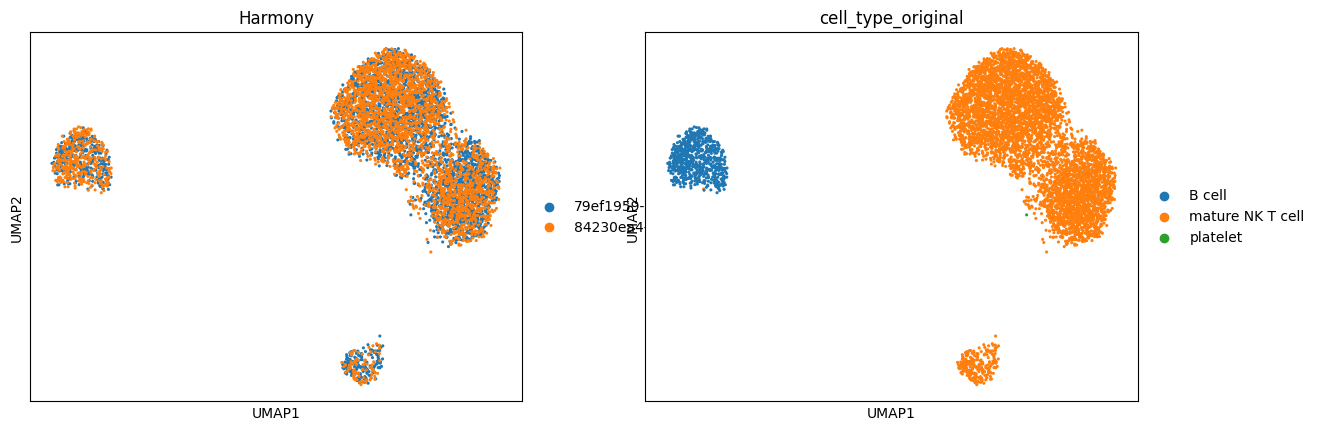

In [ ]:
sc.pp.neighbors(combined_data, use_rep='X_pca_harmony')
sc.tl.umap(combined_data)
sc.pl.umap(combined_data, color=["batch","cell_type_original"], title="Harmony")

In [ ]:
run_scetm_integration(combined_data,dataset_key='batch',celltype_key='cell_type_level1')

[2025-09-03 07:29:35,224] INFO - scETM.logging_utils: scETM.__init__(5634, 2, enable_batch_bias = True)
[2025-09-03 07:29:35,252] INFO - scETM.logging_utils: UnsupervisedTrainer.__init__(scETM(
  (q_delta): Sequential(
    (0): Linear(in_features=5634, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.1, inplace=False)
  )
  (mu_q_delta): Linear(in_features=128, out_features=50, bias=True)
  (logsigma_q_delta): Linear(in_features=128, out_features=50, bias=True)
  (rho_trainable_emb): PartlyTrainableParameter2D(height=400, fixed=0, trainable=5634)
), AnnData object with n_obs × n_vars = 6001 × 5634
    obs: 'dataset_id', 'donor_id', 'tissue_general', 'perturbation', 'chunk_number', 'filename', 'cell_index', 'dataset_dir', 'cell_type_original', 'filepath', 'filepath_harmonized', 'state', 'cell_type_level1', 'total_counts', 'n_nonzero_genes', 'max_count', '_scvi_batch', '_scvi_labels

[2025-09-03 07:29:35,674] INFO - scETM.trainers.UnsupervisedTrainer: ==========Epoch 0==========
[2025-09-03 07:29:35,675] INFO - scETM.trainers.UnsupervisedTrainer: pmem(rss=7648362496, vms=19678060544, shared=637046784, text=3207168, lib=0, data=8443748352, dirty=0)
[2025-09-03 07:29:35,675] INFO - scETM.trainers.UnsupervisedTrainer: lr          :        0.005
[2025-09-03 07:29:35,676] INFO - scETM.trainers.UnsupervisedTrainer: kl_weight   :            0
[2025-09-03 07:29:35,676] INFO - scETM.trainers.trainer_utils: loss        :      18.08
[2025-09-03 07:29:35,676] INFO - scETM.trainers.trainer_utils: nll         :      18.08
[2025-09-03 07:29:35,677] INFO - scETM.trainers.trainer_utils: kl_delta    :     0.2869
[2025-09-03 07:29:35,677] INFO - scETM.trainers.trainer_utils: max_norm    :      6.654
[2025-09-03 07:29:35,678] INFO - scETM.trainers.UnsupervisedTrainer: ==========End of evaluation==========


[2025-09-03 07:29:35,730] INFO - scETM.trainers.UnsupervisedTrainer: ==========Epoch 1==========
[2025-09-03 07:29:35,732] INFO - scETM.trainers.UnsupervisedTrainer: pmem(rss=7702417408, vms=19880529920, shared=637046784, text=3207168, lib=0, data=8592531456, dirty=0)
[2025-09-03 07:29:35,743] INFO - scETM.trainers.UnsupervisedTrainer: lr          :     0.004999
[2025-09-03 07:29:35,744] INFO - scETM.trainers.UnsupervisedTrainer: kl_weight   :        1e-07
[2025-09-03 07:29:35,744] INFO - scETM.trainers.trainer_utils: loss        :       16.8
[2025-09-03 07:29:35,745] INFO - scETM.trainers.trainer_utils: nll         :       16.8
[2025-09-03 07:29:35,747] INFO - scETM.trainers.trainer_utils: kl_delta    :       0.53
[2025-09-03 07:29:35,748] INFO - scETM.trainers.trainer_utils: max_norm    :      7.332
[2025-09-03 07:29:35,834] INFO - scETM.trainers.UnsupervisedTrainer: ==========End of evaluation==========
[2025-09-03 07:29:35,835] INFO - scETM.trainers.UnsupervisedTrainer: Optimizatio

array([[0.02246173, 0.01785025, 0.01857528, ..., 0.02002919, 0.01888815,
        0.01936315],
       [0.02247684, 0.01784442, 0.01857472, ..., 0.02004064, 0.01888304,
        0.01936274],
       [0.02246352, 0.01784275, 0.01857323, ..., 0.02002659, 0.01889286,
        0.01935946],
       ...,
       [0.02246385, 0.01785149, 0.01856583, ..., 0.02004   , 0.01888284,
        0.01936215],
       [0.02246877, 0.0178502 , 0.0185685 , ..., 0.02003689, 0.01888181,
        0.01936454],
       [0.02245886, 0.01785223, 0.01856768, ..., 0.02004237, 0.01887501,
        0.01936351]], shape=(6001, 50), dtype=float32)

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:06)


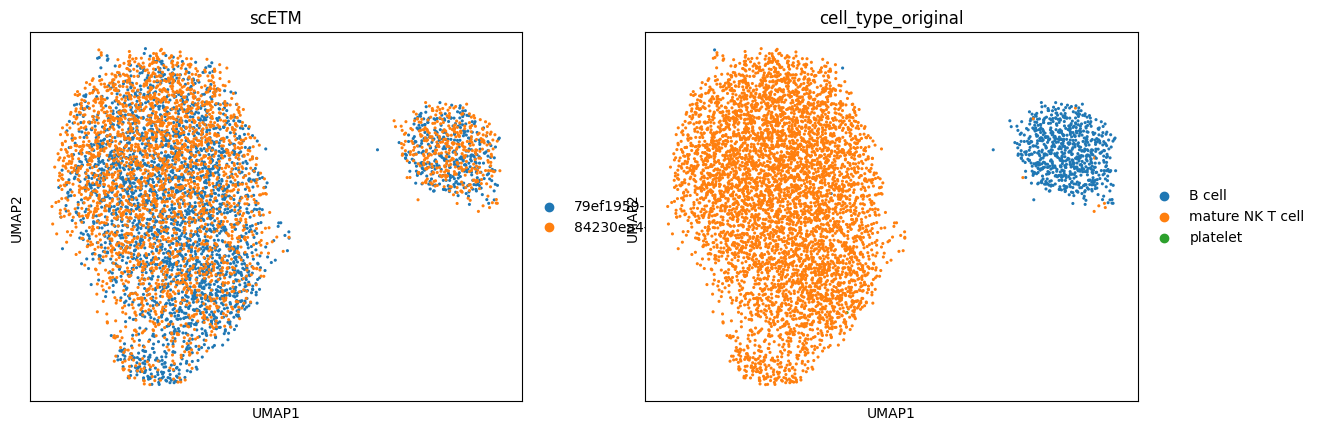

In [ ]:
sc.pp.neighbors(combined_data, use_rep="X_scetm")
sc.tl.umap(combined_data)
sc.pl.umap(combined_data, color=["batch","cell_type_level1"], title="scETM")

normalizing counts per cell
    finished (0:00:00)
computing PCA
    with n_comps=50
    finished (0:00:02)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:05)


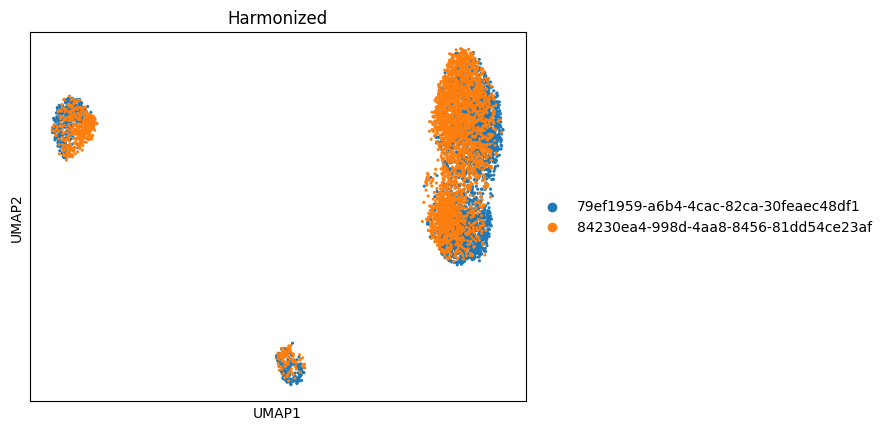

In [ ]:


sc.pp.normalize_total(adata_harmonized_sample, target_sum=1e4)
sc.pp.log1p(adata_harmonized_sample)
sc.pp.pca(adata_harmonized_sample)
sc.pp.neighbors(adata_harmonized_sample)
sc.tl.umap(adata_harmonized_sample)

sc.pl.umap(adata_harmonized_sample, color="dataset_id", title="Harmonized")

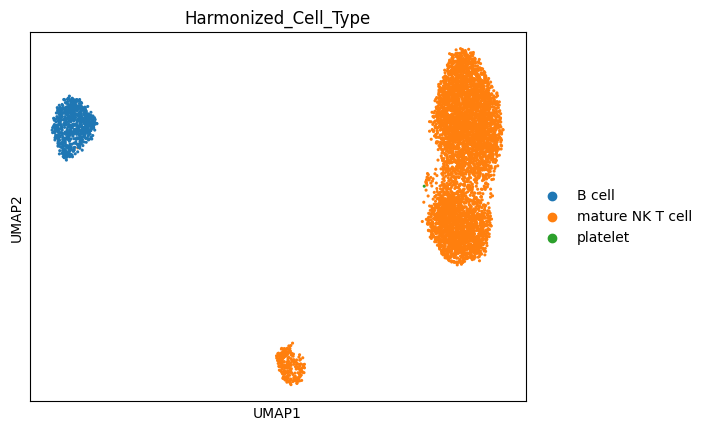

In [20]:
sc.pl.umap(adata_harmonized_selected, color="cell_type_original", title="Harmonized_Cell_Type")